11490434/11490434 [==============================] - 24s 2us/step


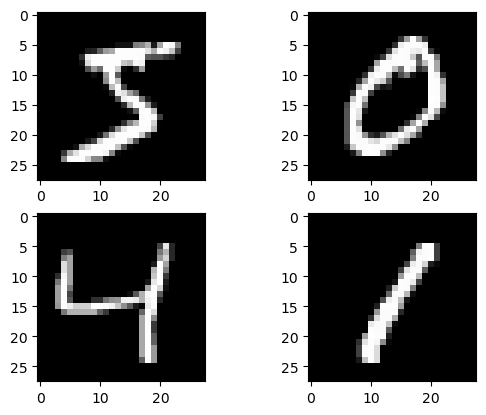

In [1]:
# Plot ad hoc mnist instances
from keras.datasets import mnist
import matplotlib.pyplot as plt

%matplotlib inline

# load (downloaded if needed) the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# plot 4 images as gray scale
plt.subplot(221)
plt.imshow(X_train[0], cmap=plt.get_cmap('gray'))
plt.subplot(222)
plt.imshow(X_train[1], cmap=plt.get_cmap('gray'))
plt.subplot(223)
plt.imshow(X_train[2], cmap=plt.get_cmap('gray'))
plt.subplot(224)
plt.imshow(X_train[3], cmap=plt.get_cmap('gray'))
# show the plot
plt.show()

#Checkout: http://myselph.de/neuralNet.html

In [2]:
import numpy
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.utils import np_utils


In [3]:
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)

In [4]:
# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(y_train[1:23])


[0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9]


In [5]:
# flatten 28*28 images to a 784 vector for each image
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32')
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32')


In [6]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

In [7]:
# one hot encode outputs
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

print(y_train[0,:])


[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [8]:
# define baseline model
def baseline_model():
    # create model
    model = Sequential()
    model.add(Dense(num_pixels, input_dim=num_pixels, kernel_initializer='normal', activation='relu'))
    model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [9]:
# build the model
model = baseline_model()
#Check your model

from tensorflow import keras

keras.utils.plot_model(model, 'blmodel1.png')


You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [10]:
# Fit the model
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Error: %.2f%%" % (100-scores[1]*100))

Epoch 1/10
300/300 - 8s - loss: 0.2798 - accuracy: 0.9211 - val_loss: 0.1473 - val_accuracy: 0.9586 - 8s/epoch - 28ms/step
Epoch 2/10
300/300 - 7s - loss: 0.1127 - accuracy: 0.9673 - val_loss: 0.0970 - val_accuracy: 0.9709 - 7s/epoch - 22ms/step
Epoch 3/10
300/300 - 6s - loss: 0.0724 - accuracy: 0.9791 - val_loss: 0.0769 - val_accuracy: 0.9768 - 6s/epoch - 21ms/step
Epoch 4/10
300/300 - 6s - loss: 0.0516 - accuracy: 0.9851 - val_loss: 0.0667 - val_accuracy: 0.9791 - 6s/epoch - 19ms/step
Epoch 5/10
300/300 - 6s - loss: 0.0372 - accuracy: 0.9894 - val_loss: 0.0697 - val_accuracy: 0.9789 - 6s/epoch - 20ms/step
Epoch 6/10
300/300 - 6s - loss: 0.0279 - accuracy: 0.9925 - val_loss: 0.0636 - val_accuracy: 0.9803 - 6s/epoch - 21ms/step
Epoch 7/10
300/300 - 7s - loss: 0.0198 - accuracy: 0.9951 - val_loss: 0.0648 - val_accuracy: 0.9791 - 7s/epoch - 22ms/step
Epoch 8/10
300/300 - 7s - loss: 0.0150 - accuracy: 0.9964 - val_loss: 0.0632 - val_accuracy: 0.9815 - 7s/epoch - 22ms/step
Epoch 9/10
300/3

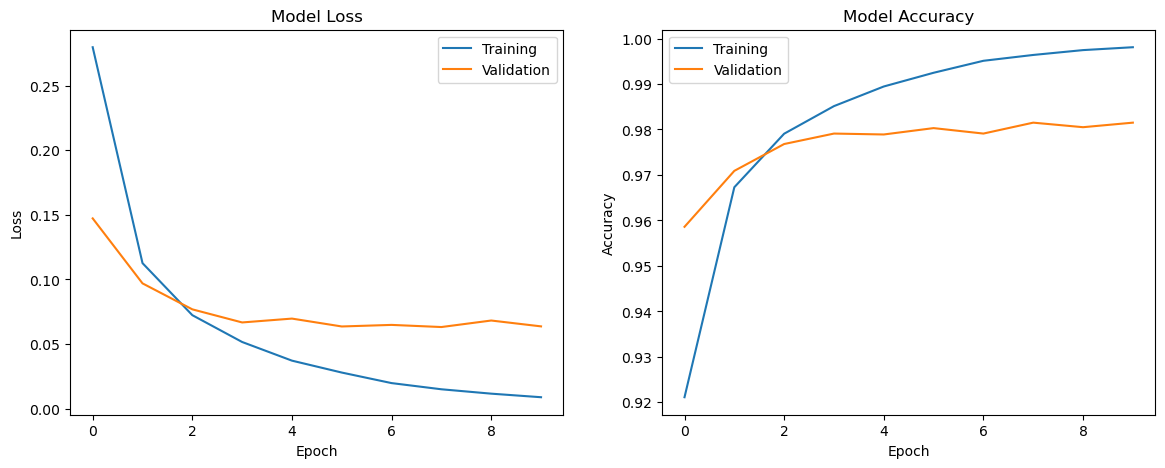

In [11]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(['Training', 'Validation'])
axes[1].plot(history.history['accuracy'])
axes[1].plot(history.history['val_accuracy'])
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(['Training', 'Validation']);

In [12]:
import numpy
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils
from keras import backend as K
#K.common.set_image_dim_ordering('th')


In [13]:
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)

In [14]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# reshape to be [samples][pixels][width][height]
X_train = X_train.reshape(X_train.shape[0], 1, 28, 28).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 1, 28, 28).astype('float32')

In [15]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255
# one hot encode outputs
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

X_train=numpy.moveaxis(X_train,1,-1)
X_test=numpy.moveaxis(X_test,1,-1)

In [16]:
def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv2D(32, (5, 5), strides=(1,1),input_shape=(28, 28, 1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [17]:
# build the model
model = baseline_model()
# Fit the model
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Error: %.2f%%" % (100-scores[1]*100))

Epoch 1/10
300/300 - 31s - loss: 0.2337 - accuracy: 0.9331 - val_loss: 0.0813 - val_accuracy: 0.9756 - 31s/epoch - 104ms/step
Epoch 2/10
300/300 - 34s - loss: 0.0752 - accuracy: 0.9782 - val_loss: 0.0516 - val_accuracy: 0.9824 - 34s/epoch - 113ms/step
Epoch 3/10
300/300 - 30s - loss: 0.0528 - accuracy: 0.9840 - val_loss: 0.0432 - val_accuracy: 0.9857 - 30s/epoch - 99ms/step
Epoch 4/10
300/300 - 28s - loss: 0.0426 - accuracy: 0.9868 - val_loss: 0.0378 - val_accuracy: 0.9881 - 28s/epoch - 94ms/step
Epoch 5/10
300/300 - 38s - loss: 0.0351 - accuracy: 0.9889 - val_loss: 0.0326 - val_accuracy: 0.9901 - 38s/epoch - 127ms/step
Epoch 6/10
300/300 - 32s - loss: 0.0280 - accuracy: 0.9913 - val_loss: 0.0353 - val_accuracy: 0.9886 - 32s/epoch - 107ms/step
Epoch 7/10
300/300 - 32s - loss: 0.0230 - accuracy: 0.9927 - val_loss: 0.0321 - val_accuracy: 0.9896 - 32s/epoch - 108ms/step
Epoch 8/10
300/300 - 31s - loss: 0.0195 - accuracy: 0.9937 - val_loss: 0.0305 - val_accuracy: 0.9892 - 31s/epoch - 105ms

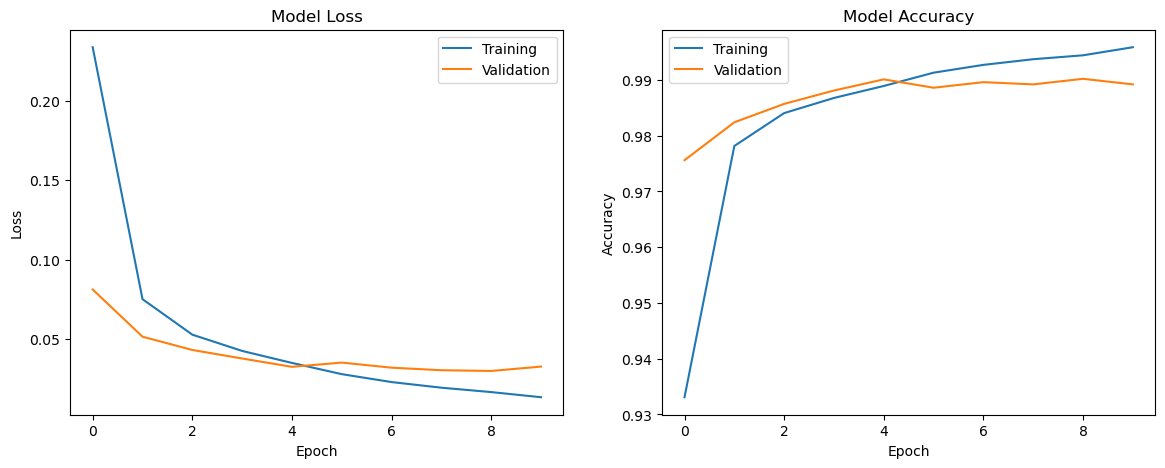

In [18]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(['Training', 'Validation'])
axes[1].plot(history.history['accuracy'])
axes[1].plot(history.history['val_accuracy'])
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(['Training', 'Validation']);

In [19]:
 # Test another model
def baseline_model2():
    model = Sequential()
 
    model.add(Conv2D(32, 3, 3, activation='relu', input_shape=(28,28,1)))
    model.add(Conv2D(32, 3, 3, activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25)) 
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model   
    

In [20]:
# build the model
model = baseline_model2()
# Fit the model
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline2 Error: %.2f%%" % (100-scores[1]*100))

Epoch 1/10
300/300 - 6s - loss: 1.2523 - accuracy: 0.5889 - val_loss: 0.5286 - val_accuracy: 0.8448 - 6s/epoch - 20ms/step
Epoch 2/10
300/300 - 4s - loss: 0.7383 - accuracy: 0.7715 - val_loss: 0.4241 - val_accuracy: 0.8762 - 4s/epoch - 13ms/step
Epoch 3/10
300/300 - 4s - loss: 0.6348 - accuracy: 0.8070 - val_loss: 0.3751 - val_accuracy: 0.8904 - 4s/epoch - 15ms/step
Epoch 4/10
300/300 - 4s - loss: 0.5826 - accuracy: 0.8215 - val_loss: 0.3394 - val_accuracy: 0.9023 - 4s/epoch - 12ms/step
Epoch 5/10
300/300 - 4s - loss: 0.5495 - accuracy: 0.8339 - val_loss: 0.3281 - val_accuracy: 0.9041 - 4s/epoch - 13ms/step
Epoch 6/10
300/300 - 4s - loss: 0.5217 - accuracy: 0.8413 - val_loss: 0.3055 - val_accuracy: 0.9083 - 4s/epoch - 13ms/step
Epoch 7/10
300/300 - 4s - loss: 0.5004 - accuracy: 0.8480 - val_loss: 0.2959 - val_accuracy: 0.9124 - 4s/epoch - 13ms/step
Epoch 8/10
300/300 - 4s - loss: 0.4831 - accuracy: 0.8532 - val_loss: 0.2813 - val_accuracy: 0.9157 - 4s/epoch - 12ms/step
Epoch 9/10
300/3

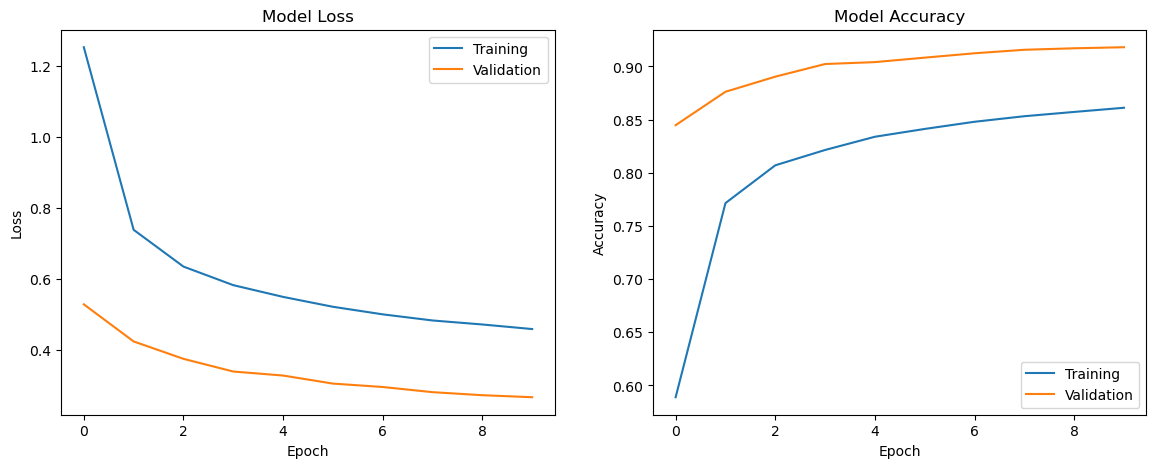

In [21]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(['Training', 'Validation'])
axes[1].plot(history.history['accuracy'])
axes[1].plot(history.history['val_accuracy'])
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(['Training', 'Validation']);

In [22]:
# Larger CNN for the MNIST Dataset


In [23]:
# define the larger model
def larger_model():
    # create model
    model = Sequential()
    model.add(Conv2D(30, (5, 5), input_shape=(28, 28, 1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(15, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [24]:
# build the model
model = larger_model()
# Fit the model
history=model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=150)
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Large CNN Error: %.2f%%" % (100-scores[1]*100))

Epoch 1/30
400/400 [==============================] - 37s 89ms/step - loss: 0.3356 - accuracy: 0.8956 - val_loss: 0.0684 - val_accuracy: 0.9786
Epoch 2/30
400/400 [==============================] - 37s 93ms/step - loss: 0.0866 - accuracy: 0.9739 - val_loss: 0.0418 - val_accuracy: 0.9868
Epoch 3/30
400/400 [==============================] - 34s 85ms/step - loss: 0.0621 - accuracy: 0.9811 - val_loss: 0.0318 - val_accuracy: 0.9900
Epoch 4/30
400/400 [==============================] - 36s 90ms/step - loss: 0.0502 - accuracy: 0.9843 - val_loss: 0.0352 - val_accuracy: 0.9898
Epoch 5/30
400/400 [==============================] - 37s 92ms/step - loss: 0.0434 - accuracy: 0.9866 - val_loss: 0.0289 - val_accuracy: 0.9898
Epoch 6/30
400/400 [==============================] - 34s 86ms/step - loss: 0.0383 - accuracy: 0.9878 - val_loss: 0.0279 - val_accuracy: 0.9905
Epoch 7/30
400/400 [==============================] - 30s 75ms/step - loss: 0.0348 - accuracy: 0.9889 - val_loss: 0.0247 - val_accuracy:

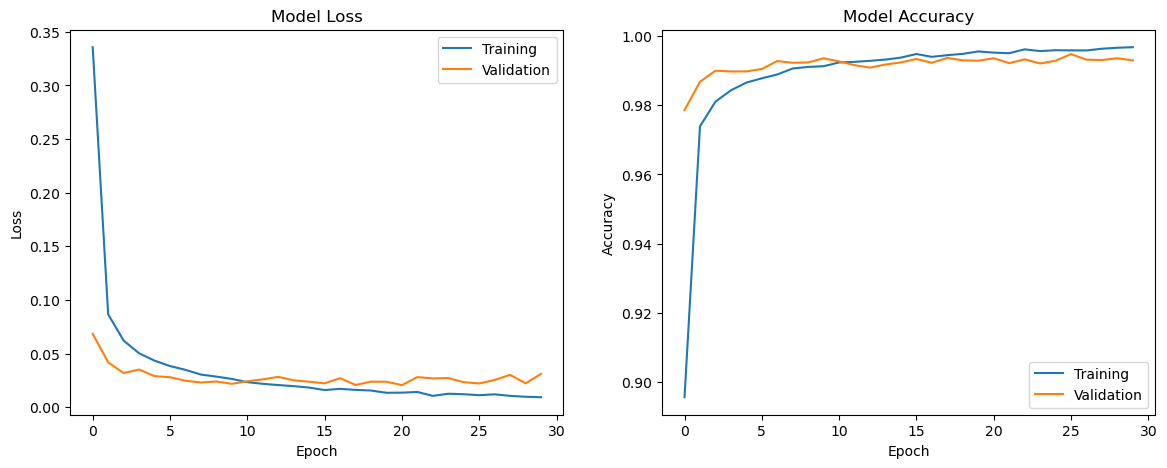

In [25]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(['Training', 'Validation'])
axes[1].plot(history.history['accuracy'])
axes[1].plot(history.history['val_accuracy'])
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(['Training', 'Validation']);